In [1]:
import pandas as pd
import ast
import json
import time
import requests
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import numpy as np
from sklearn.ensemble import  RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

def search_track_id(artist, track):
    query = f'track:"{track}" artist:"{artist}"'
    result = sp.search(q=query, type="track", limit=1)

    items = result.get("tracks", {}).get("items", [])
    if not items:
        return None

    return items[0]["id"]

def get_reccobeats_features(spotify_ids, batch_size=40):
    spotify_ids = [sid for sid in spotify_ids if pd.notna(sid) and sid is not None]

    if not spotify_ids:
        return []

    all_features = []

    for i in range(0, len(spotify_ids), batch_size):
        batch = spotify_ids[i:i + batch_size]

        response = requests.get(
            "https://api.reccobeats.com/v1/audio-features",
            params={"ids": ",".join(batch)},
            headers={"Accept": "application/json"}
        )
        response.raise_for_status()

        batch_features = response.json().get("content", [])
        all_features.extend(batch_features)

        print(f"Fetched features for batch {i // batch_size + 1} ({len(batch)} songs)")
        time.sleep(0.1)

    return all_features

def extract_first_artist(x):
    if pd.isna(x):
        return None

    # if already a list
    if isinstance(x, list):
        return x[0] if len(x) > 0 else None

    # if stored like "['Artist Name']"
    if isinstance(x, str):
        parsed = ast.literal_eval(x)
        if isinstance(parsed, list) and len(parsed) > 0:
            return parsed[0]
    return None

/Users/treoconnell/PycharmProjects/Music_Recommendation_Machine_Learning/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [7]:
# Loading user data from csv
df = pd.read_csv("data/tre_lastfm.csv", sep=",")
df.columns = df.columns.str.strip().str.lower()

print("Original columns:")
print(df.columns.tolist())
print()

rename_map = {
    "song": "track",
    "song name": "track",
    "track name": "track",
    "artist name": "artist",
    "plays": "count",
    "playcount": "count",
    "play_count": "count",
    "scrobbles": "count"
}
df = df.rename(columns=rename_map)

required_basic = ["artist", "track"]
missing_basic = [col for col in required_basic if col not in df.columns]

if "count" not in df.columns:
    df["count"] = 1

df = df[["artist", "track", "count"]].copy()
df["artist"] = df["artist"].astype(str).str.strip()
df["track"] = df["track"].astype(str).str.strip()
df = df[(df["artist"] != "") & (df["track"] != "")]
df = (
    df.groupby(["artist", "track"], as_index=False)["count"]
    .sum()
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)


Original columns:
['uts', 'utc_time', 'artist', 'artist_mbid', 'album', 'album_mbid', 'track', 'track_mbid']



In [8]:
# Loading up the spotify API
with open("credentials.json", "r") as f:
    creds = json.load(f)

sp = spotipy.Spotify(
    auth_manager=SpotifyClientCredentials(
        client_id=creds["CLIENT_ID"],
        client_secret=creds["CLIENT_SECRET"]
    )
)

In [9]:
# Getting spotify song IDs, so we can plug those into reccobeats
unique_songs = df[["artist", "track"]].drop_duplicates().reset_index(drop=True)

spotify_ids = []

print("Searching Spotify for IDs...")
for i, row in unique_songs.iterrows():
    artist = row["artist"]
    track = row["track"]
    spotify_id = search_track_id(artist, track)

    spotify_ids.append(spotify_id)

    if (i + 1) % 25 == 0 or i == len(unique_songs) - 1:
        print(f"Processed {i + 1}/{len(unique_songs)}")

    time.sleep(0.1)

unique_songs["spotify_id"] = spotify_ids
print(unique_songs)

Searching Spotify for IDs...
Processed 25/803
Processed 50/803
Processed 75/803
Processed 100/803
Processed 125/803
Processed 150/803
Processed 175/803
Processed 200/803
Processed 225/803
Processed 250/803
Processed 275/803
Processed 300/803
Processed 325/803
Processed 350/803
Processed 375/803
Processed 400/803
Processed 425/803
Processed 450/803
Processed 475/803
Processed 500/803
Processed 525/803
Processed 550/803
Processed 575/803
Processed 600/803
Processed 625/803


Your application has reached a rate/request limit. Retry will occur after: 86117 s


KeyboardInterrupt: 

In [18]:
unique_songs_new = unique_songs[:628]
unique_songs_new["spotify_id"] = spotify_ids

/var/folders/6d/2mbd2mln53q_kwk5wx_hq5ww0000gn/T/ipykernel_5247/1691040033.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_songs_new["spotify_id"] = spotify_ids


In [27]:
# Calling reccobeats API to get the audo features for the songs
print("Fetching ReccoBeats audio features...")
features = get_reccobeats_features(unique_songs_new["spotify_id"].tolist())

# Build map using Spotify ID extracted from href
feature_map = {}

for feat in features:
    href = feat.get("href")
    if href and "/track/" in href:
        spotify_id_from_href = href.split("/track/")[-1].split("?")[0]
        feature_map[spotify_id_from_href] = feat

feature_rows = []
for _, row in unique_songs_new.iterrows():
    sid = row["spotify_id"]
    feat = feature_map.get(sid, {})

    feature_rows.append({
        "artist": row["artist"],
        "track": row["track"],
        "spotify_id": sid,
        "danceability": feat.get("danceability"),
        "energy": feat.get("energy"),
        "tempo": feat.get("tempo"),
        "valence": feat.get("valence"),
        "acousticness": feat.get("acousticness"),
        "instrumentalness": feat.get("instrumentalness"),
        "liveness": feat.get("liveness"),
        "speechiness": feat.get("speechiness"),
        "loudness": feat.get("loudness"),
        "key": feat.get("key"),
        "mode": feat.get("mode")
    })

features_df = pd.DataFrame(feature_rows)

Fetching ReccoBeats audio features...
Fetched features for batch 1 (40 songs)
Fetched features for batch 2 (40 songs)
Fetched features for batch 3 (40 songs)
Fetched features for batch 4 (40 songs)
Fetched features for batch 5 (40 songs)
Fetched features for batch 6 (40 songs)
Fetched features for batch 7 (40 songs)
Fetched features for batch 8 (40 songs)
Fetched features for batch 9 (40 songs)
Fetched features for batch 10 (40 songs)
Fetched features for batch 11 (40 songs)
Fetched features for batch 12 (40 songs)
Fetched features for batch 13 (40 songs)
Fetched features for batch 14 (40 songs)
Fetched features for batch 15 (40 songs)
Fetched features for batch 16 (28 songs)


[]

In [28]:
# Putting the newly drawn features back into our dataframe
final_df = df.merge(features_df, on=["artist", "track"], how="left")

In [29]:
# Saving the new dataset to a csv
final_df.to_csv("data/tre_lastfm_with_features.csv", index=False)
print("Saved to data/tre_lastfm_with_features.csv")
print()

Saved to data/tre_lastfm_with_features.csv



In [30]:
# Identifying numerical columns.
feature_cols = [
    "danceability",
    "energy",
    "tempo",
    "valence",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness",
    "loudness",
    "key",
    "mode"
]

# Dropping tracks with no numerical data.
clean_df = final_df.dropna(subset=feature_cols).copy()

In [31]:
user_profile = (
    clean_df[feature_cols]
    .multiply(clean_df["count"], axis=0)
    .sum() / clean_df["count"].sum()
)

print(user_profile)

danceability          0.600205
energy                0.633782
tempo               123.806612
valence               0.438532
acousticness          0.217610
instrumentalness      0.077631
liveness              0.188360
speechiness           0.072215
loudness             -6.664129
key                   5.289817
mode                  0.574413
dtype: float64


In [32]:
# Putting the big song csv file into a dataframe
songs_db = pd.read_csv("data/tracks_features.csv")
songs_db.columns = songs_db.columns.str.strip().str.lower()

In [33]:
# Changing column names so api features match what's in the big dataframe
songs_db = songs_db.rename(columns={"name": "track"})
# Some songs have multiple artists, this one pulls only the first one
songs_db["artist"] = songs_db["artists"].apply(extract_first_artist)

In [34]:
# Removing columns that we don't need.
required_cols = ["artist", "track"] + feature_cols

songs_db = songs_db[required_cols].copy()

songs_db["artist"] = songs_db["artist"].astype(str).str.strip()
songs_db["track"] = songs_db["track"].astype(str).str.strip()

songs_db = songs_db.dropna(subset=["artist", "track"] + feature_cols).copy()

print("Songs in DB after cleaning:", len(songs_db))

Songs in DB after cleaning: 1204025


In [35]:
# Removing songs user already listened to from the big dataframe
heard_songs = clean_df[["artist", "track"]].drop_duplicates().copy()

candidate_df = songs_db.merge(
    heard_songs,
    on=["artist", "track"],
    how="left",
    indicator=True
)

candidate_df = candidate_df[candidate_df["_merge"] == "left_only"].drop(columns=["_merge"])

print("Candidate songs left after removing heard songs:", len(candidate_df))
print()

Candidate songs left after removing heard songs: 1203952



In [36]:
# Inserting some unheard songs, so the model can better predict.
positive_df = clean_df.copy()
positive_df["liked"] = 1

negative_df = candidate_df.sample(n=len(positive_df), random_state=17).copy()
negative_df["liked"] = 0
negative_df["count"] = 0

train_df = pd.concat([positive_df, negative_df], ignore_index=True)

X = train_df[feature_cols]
y = train_df["count"]

In [37]:
# Actually training the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Model evaluation:")

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R^2:", r2)
print()

Model evaluation:
MSE: 4.732551054216867
RMSE: 2.17544272602541
MAE: 0.9971987951807229
R^2: -0.04350681227145059



In [38]:
# Giving recommendations
candidate_X = candidate_df[feature_cols]
candidate_df["predicted_count"] = model.predict(candidate_X)
recommendations = candidate_df.sort_values(
    "predicted_count",
    ascending=False
)

In [39]:
recommendations.head(20)

,artist,track,danceability,energy,tempo,valence,acousticness,instrumentalness,liveness,speechiness,loudness,key,mode,predicted_count
1004818,Artur Mena,Warmicita Hilandera,0.842,0.736,102.555,0.877,0.699000,0.000002,0.0647,0.0308,-5.000,11,0,10.670
961431,Soda Stereo,Trátame Suavemente - Remasterizado 2007,0.738,0.789,122.852,0.539,0.040100,0.064700,0.6320,0.0283,-4.009,11,0,10.430
999312,Alicia Keys,Rapture,0.725,0.826,113.980,0.566,0.005530,0.000617,0.6200,0.0302,-4.062,11,0,10.380
1132841,Starseed Dro,Bonnie Doone,0.704,0.754,138.002,0.509,0.091300,0.000000,0.6240,0.0403,-5.078,11,1,10.070
1007563,Dorio,10 Years,0.734,0.804,112.054,0.745,0.092900,0.029900,0.6210,0.0674,-4.982,5,1,9.980
1007377,Dorio,10 Years,0.734,0.804,112.054,0.745,0.092900,0.029900,0.6210,0.0674,-4.982,5,1,9.980
686596,Sonny Fodera,Feeling You (feat. Yasmin) - Deep Mix,0.808,0.552,121.996,0.602,0.039200,0.157000,0.6250,0.0530,-5.219,0,1,9.930
1071174,Urbs & Cutex,Right Where-!,0.724,0.701,97.407,0.504,0.008630,0.785000,0.6300,0.0255,-4.894,8,1,9.815
712670,Shigeo Tamaru,Nothing After Chaos,0.621,0.808,155.918,0.599,0.124000,0.593000,0.6210,0.0326,-3.151,6,0,9.815
1067536,Shai Linne,C.H.R.I.S.T.,0.766,0.706,92.052,0.383,0.234000,0.000000,0.6230,0.1230,-5.047,11,1,9.780


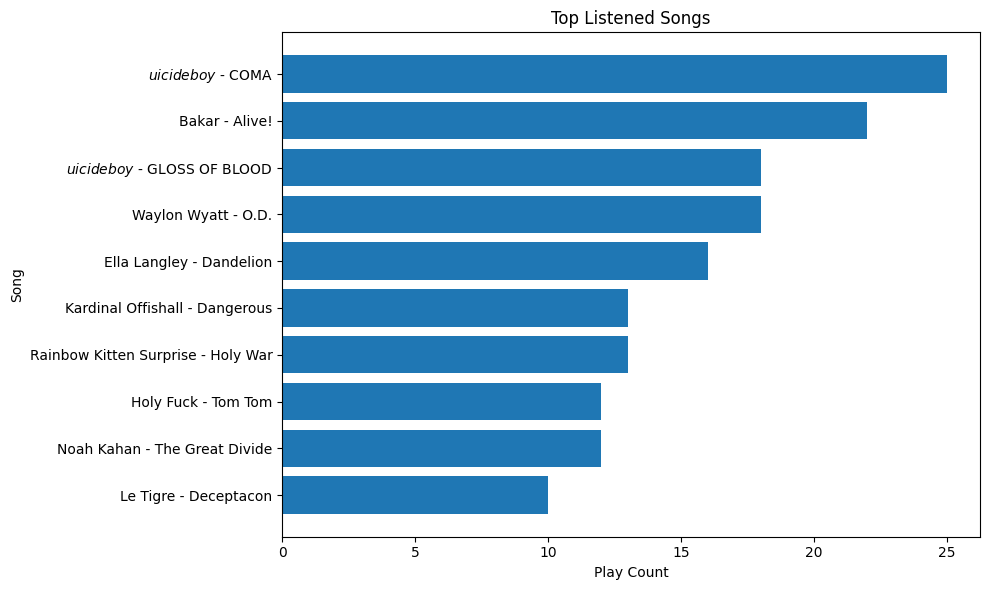

In [40]:
top_songs = clean_df.sort_values("count", ascending=False).head(10).copy()
top_songs["label"] = top_songs["artist"] + " - " + top_songs["track"]

plt.figure(figsize=(10, 6))
plt.barh(top_songs["label"][::-1], top_songs["count"][::-1])
plt.xlabel("Play Count")
plt.ylabel("Song")
plt.title("Top Listened Songs")
plt.tight_layout()
plt.show()

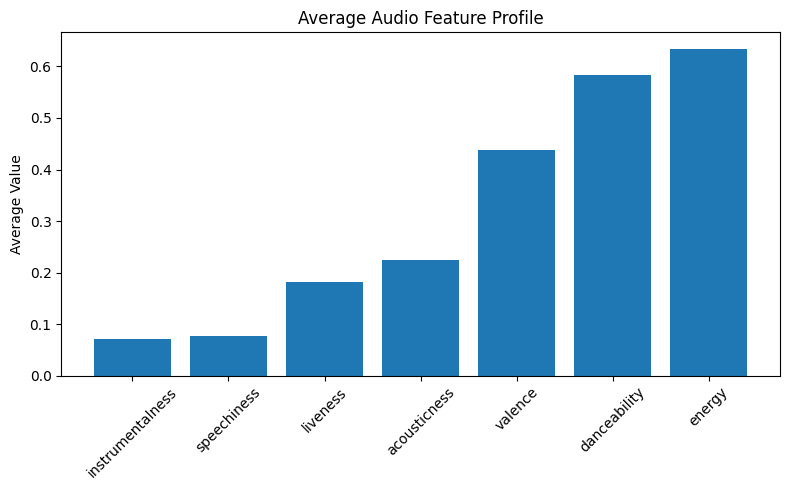

In [41]:
profile_features = [
    "danceability", "energy", "valence", "acousticness",
    "instrumentalness", "liveness", "speechiness"
]

avg_profile = clean_df[profile_features].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.bar(avg_profile.index, avg_profile.values)
plt.ylabel("Average Value")
plt.title("Average Audio Feature Profile")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

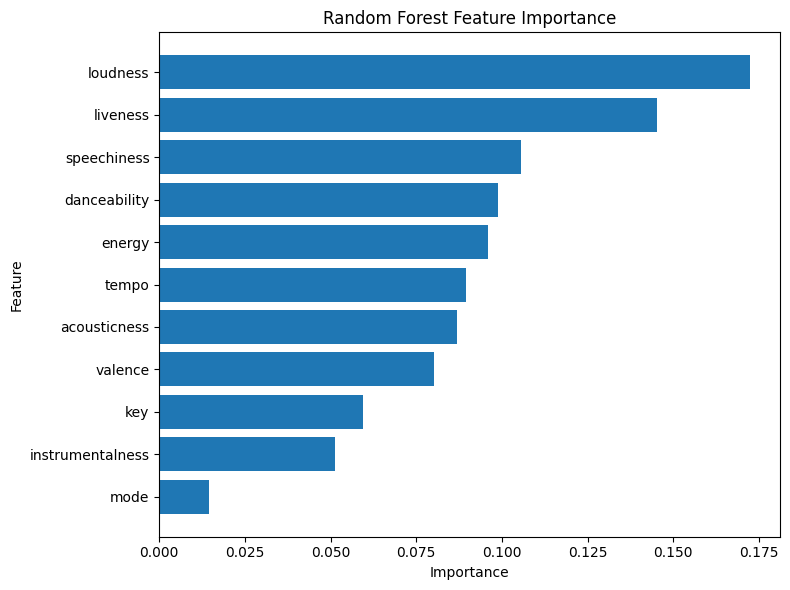

In [42]:
importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(importance.index, importance.values)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()